In [147]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [148]:
# load data

df = pd.read_csv("loan_data.csv", low_memory =False)
df.head()

,new_customer,application_date,income_verification,language,date_of_birth,gender,country,loan_amount,county,city,...,credit_score_1,credit_score_2,credit_score_3,credit_score_4,nr_previous_loans,amount_previous_loans,previous_repayments,previous_early_repayments,previous_early_repayments_count,default
0,1,2013-06-10 16:40:39,unverified,estonian,1951-11-25,female,EE,319.5582,HARJU,TALLINN,...,NaN,NaN,NaN,NaN,1,83.0852,0.0000,0.0,0,0
1,0,2013-06-09 15:48:57,unverified,estonian,1964-11-04,female,EE,191.7349,IDA-VIRU,KOHTLA-JARVE,...,NaN,NaN,NaN,NaN,2,255.6467,258.6256,0.0,0,0
2,1,2013-06-04 19:12:29,unverified,estonian,1954-11-12,female,EE,319.5582,PÄRNU,PÄRNU,...,NaN,NaN,NaN,NaN,0,0.0000,0.0000,0.0,0,1
3,1,2013-06-12 12:01:20,unverified,estonian,1990-03-28,female,EE,127.8233,HARJU,PALDISKI,...,NaN,NaN,NaN,NaN,1,134.2144,0.0000,0.0,0,0
4,1,2013-06-09 10:17:13,unverified,estonian,1987-09-29,female,EE,319.5582,TARTU,TARTU,...,NaN,NaN,NaN,NaN,1,146.9966,0.0000,0.0,0,1


In [149]:
seed = 10

In [150]:
# Split the data set into a train set containing 80% of the customers and a test set containing the remaining 20%:

X_train, X_test, y_train, y_test = train_test_split(
    df.drop("default", axis=1),
    df["default"],
    test_size = 0.20,
    random_state=seed,
)

# Inspect the shape of the resulting data sets:

X_train.shape, X_test.shape
    

((56530, 38), (14133, 38))

In [151]:
#calculate the default rate in each data set

#The default rate is about 65%. As the data sets were generated by random splits, you get similar a default rate in each data set:

#You now have 2 datasets with randomly allocated customers. 
#The train set contains 80% of the customers, and the test set contains 20% of the customers. 
#The default rate in the data sets is ~65%.

y_train.mean(), y_test.mean()

(0.6570493543251371, 0.6432463029788439)

In [152]:
import matplotlib.pyplot as plt

In [153]:
# find numerical variables

var_num = list(X_train.select_dtypes(include="number").columns)

var_num

['new_customer',
 'loan_amount',
 'nr_dependants',
 'income_from_employer',
 'income_from_pension',
 'income_from_family_allowance',
 'income_from_social_welfare',
 'income_from_leave_pay',
 'income_from_child_support',
 'income_other',
 'nr_debt_items',
 'total_debt',
 'credit_score_4',
 'nr_previous_loans',
 'amount_previous_loans',
 'previous_repayments',
 'previous_early_repayments',
 'previous_early_repayments_count']

In [154]:
# find discrete variables

var_discrete = [var for var in var_num if X_train[var].nunique() < 20]

var_discrete

['new_customer',
 'nr_dependants',
 'credit_score_4',
 'previous_early_repayments_count']

In [155]:
# Examine discrete variable values

for var in var_discrete:
    print(var)
    print(X_train[var].value_counts(normalize=True))
    print()

new_customer
new_customer
1    0.559066
0    0.440934
Name: proportion, dtype: float64

nr_dependants
nr_dependants
0.0     0.561921
1.0     0.235011
2.0     0.140656
3.0     0.045282
4.0     0.012356
5.0     0.003370
6.0     0.000702
7.0     0.000456
18.0    0.000035
11.0    0.000035
8.0     0.000035
20.0    0.000035
13.0    0.000035
12.0    0.000035
15.0    0.000035
Name: proportion, dtype: float64

credit_score_4
credit_score_4
1000.0    0.778759
800.0     0.077712
900.0     0.071201
600.0     0.036519
700.0     0.035488
500.0     0.000322
Name: proportion, dtype: float64

previous_early_repayments_count
previous_early_repayments_count
0    0.929754
1    0.054467
2    0.010366
3    0.003449
4    0.001079
5    0.000283
7    0.000265
6    0.000195
8    0.000124
9    0.000018
Name: proportion, dtype: float64



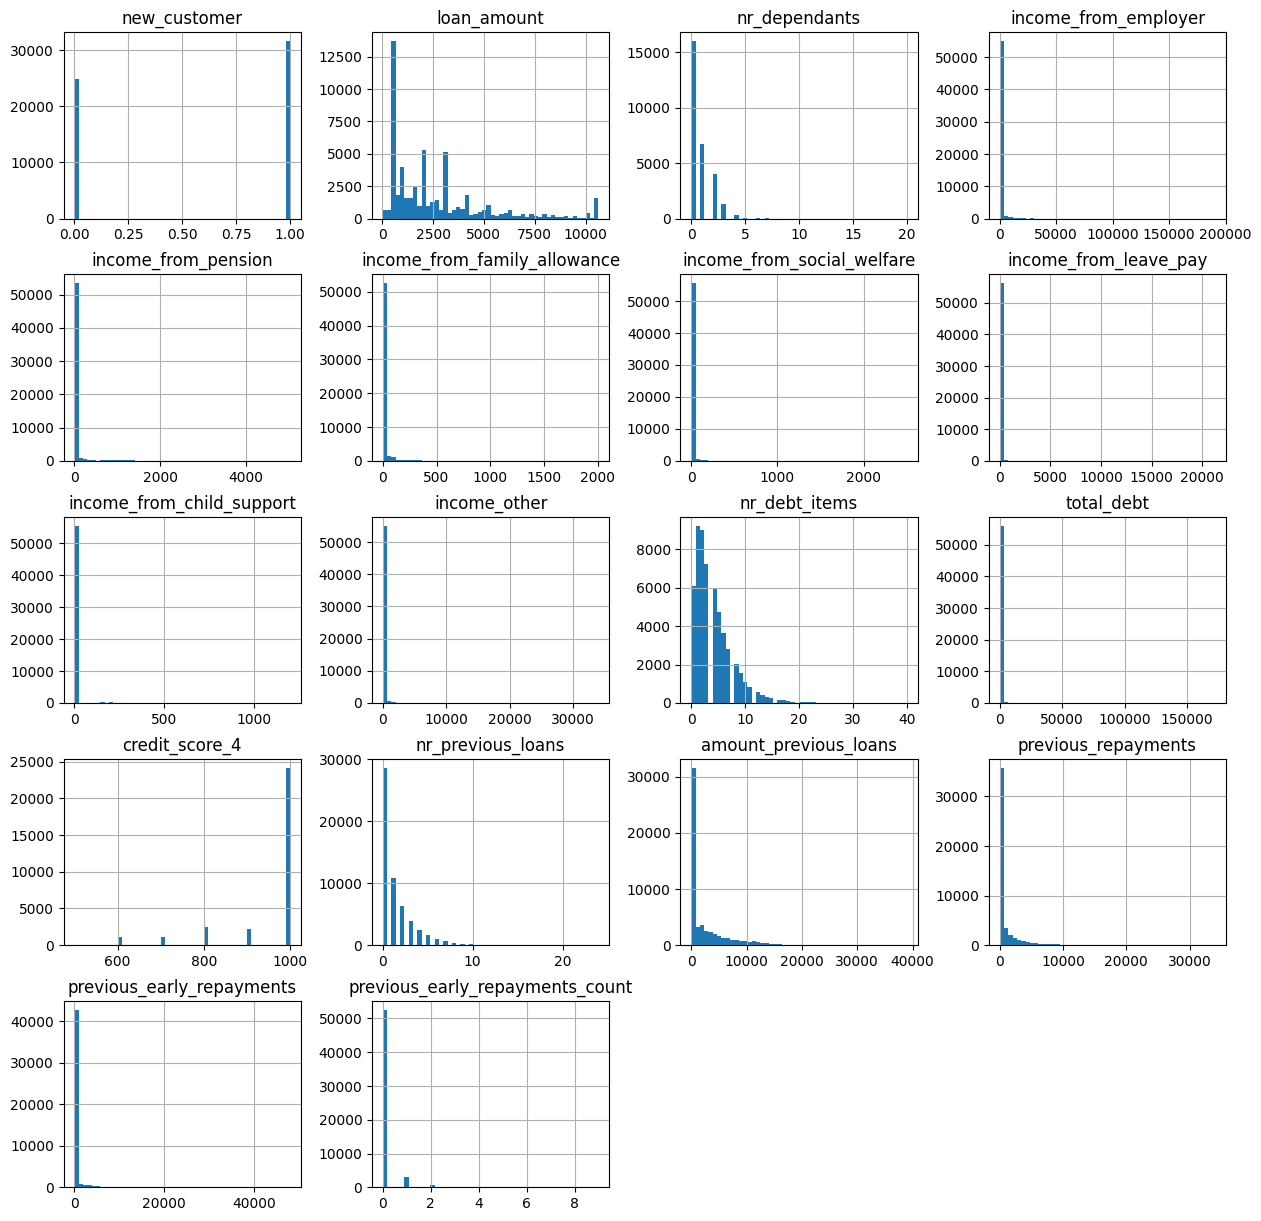

In [156]:
# Examine numerical variable distributions

fig = X_train[var_num].hist(bins=50, figsize=(15,15))
plt.show()

In [157]:
from feature_engine.imputation import ArbitraryNumberImputer

In [158]:
# Identify numerical variables with missing data

var_num_na = [var for var in var_num if X_train[var].isnull().sum() > 0]

var_num_na


['nr_dependants',
 'credit_score_4',
 'previous_repayments',
 'previous_early_repayments']

In [159]:
# Find maximum and minimum values

X_train[var_num_na].describe()


,nr_dependants,credit_score_4,previous_repayments,previous_early_repayments
count,28488.000000,31025.000000,48257.000000,45528.000000
mean,0.729254,951.922643,980.815380,260.953051
std,1.026533,103.086680,2327.506222,1399.392338
min,0.000000,500.000000,0.000000,0.000000
25%,0.000000,1000.000000,0.000000,0.000000
50%,0.000000,1000.000000,0.000000,0.000000
75%,1.000000,1000.000000,735.380000,0.000000
max,20.000000,1000.000000,34077.420000,48100.000000


In [160]:
# Set up the imputer

imputer = ArbitraryNumberImputer(
    arbitrary_number=-1,  # the imputation value
    variables=var_num_na, # the variables to impute
)

In [161]:
# Impute variables

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Check that imputation worked
X_test[var_num_na].isnull().sum()

nr_dependants                0
credit_score_4               0
previous_repayments          0
previous_early_repayments    0
dtype: int64

**Create income and debt related variables**

In [162]:
# Total income -: Income variables

var_income = [
    "income_from_employer",
    "income_from_pension",
    "income_from_family_allowance",
    "income_from_social_welfare",
    "income_from_leave_pay",
    "income_from_child_support",
    "income_other",
]

In [163]:
# Create total income variable

X_train["total_income"] = X_train[var_income].sum(axis=1)
X_test["total_income"] = X_test[var_income].sum(axis=1)

# Examine variable
X_train[var_income + ["total_income"]].head()

,income_from_employer,income_from_pension,income_from_family_allowance,income_from_social_welfare,income_from_leave_pay,income_from_child_support,income_other,total_income
11155,0.0,568.0,0.0,0.0,0.0,470.0,0.0,1038.0
50730,1100.0,0.0,0.0,0.0,0.0,0.0,0.0,1100.0
35924,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
69230,955.0,0.0,0.0,0.0,0.0,0.0,0.0,955.0
35679,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


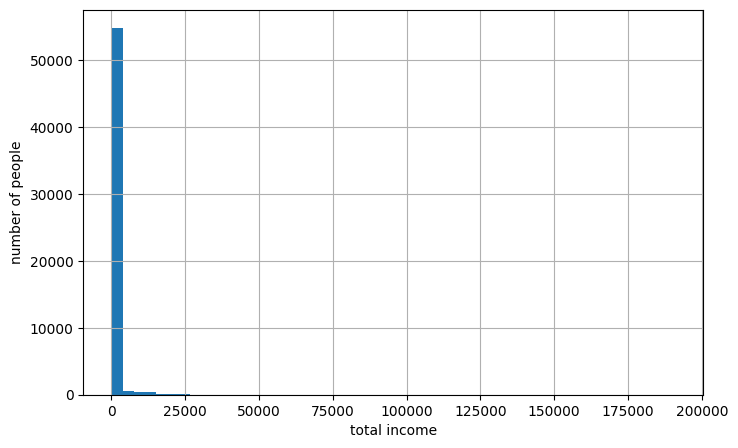

In [164]:
# PLot income distribution

X_train["total_income"].hist(bins=50, figsize=(8, 5))
plt.ylabel("number of people")
plt.xlabel("total income")
plt.show()


Most people have 0 income.

In [165]:
X_train.shape

(56530, 39)

In [166]:
X_train[X_train["total_income"] == 0].shape

(27299, 39)

In [167]:
y_train[X_train["total_income"] == 0].mean()

0.6649327814205649

In [168]:
y_train[X_train["total_income"] != 0].mean()

0.6496869761554515

The percentage of default among the people who declare their income is more or less the same as that of those who do not declare their income.

**Debt to income ratio**

The debt-to-income (DTI) ratio is the percentage of the gross monthly income that goes to 
paying monthly debt payments and is used by lenders to determine the person's borrowing risk.

In [169]:
# Create variable dti

X_train["dti"] = X_train["total_debt"].div(X_train["total_income"])
X_test["dti"] = X_test["total_debt"].div(X_test["total_income"])

X_train[["dti", "total_debt", "total_income"]].head()

,dti,total_debt,total_income
11155,0.822736,854.0,1038.0
50730,0.428182,471.0,1100.0
35924,NaN,0.0,0.0
69230,0.299476,286.0,955.0
35679,inf,245.4,0.0


In [171]:
# Division by 0 creates nan and infinity, let's remove
import numpy as np

X_train["dti"] = np.where(np.isfinite(X_train["dti"]), X_train["dti"], 0)
X_test["dti"] = np.where(np.isfinite(X_test["dti"]), X_test["dti"], 0)

In [172]:
print(X_train.columns.tolist())

['new_customer', 'application_date', 'income_verification', 'language', 'date_of_birth', 'gender', 'country', 'loan_amount', 'county', 'city', 'use_of_loan', 'education', 'marital_status', 'nr_dependants', 'employment_status', 'employment_duration', 'employment_position', 'work_experience', 'occupation', 'home_ownership', 'income_from_employer', 'income_from_pension', 'income_from_family_allowance', 'income_from_social_welfare', 'income_from_leave_pay', 'income_from_child_support', 'income_other', 'nr_debt_items', 'total_debt', 'credit_score_1', 'credit_score_2', 'credit_score_3', 'credit_score_4', 'nr_previous_loans', 'amount_previous_loans', 'previous_repayments', 'previous_early_repayments', 'previous_early_repayments_count', 'total_income', 'dti']


In [173]:
import numpy as np

# Replace inf with nan first, then compute median cleanly
dti_train = X_train["dti"].copy()
dti_train = dti_train.replace([np.inf, -np.inf], np.nan)

median_dti = dti_train.median()  # safely ignores nan

# Apply using numpy where — no inplace, no downcasting warning
X_train["dti"] = np.where(
    np.isinf(X_train["dti"]) | X_train["dti"].isna(), 
    median_dti, 
    X_train["dti"]
)
X_test["dti"] = np.where(
    np.isinf(X_test["dti"]) | X_test["dti"].isna(), 
    median_dti, 
    X_test["dti"]
)

In [174]:
import numpy as np

# Step 1: inspect
print(X_train["dti"].describe())
print("inf count:", np.isinf(X_train["dti"]).sum())
print("nan count:", X_train["dti"].isna().sum())
print("valid count:", np.isfinite(X_train["dti"]).sum())

count    56530.000000
mean         0.312232
std          0.423591
min          0.000000
25%          0.000000
50%          0.000000
75%          0.558247
max         30.234521
Name: dti, dtype: float64
inf count: 0
nan count: 0
valid count: 56530


In [175]:
# Step 2: safe replace — fallback to 0 if no finite values exist
finite_vals = X_train["dti"][np.isfinite(X_train["dti"])]

median_dti = finite_vals.median() if len(finite_vals) > 0 else 0

print(f"Replacing inf/nan with: {median_dti}")

X_train["dti"] = np.where(np.isfinite(X_train["dti"]), X_train["dti"], median_dti)
X_test["dti"] = np.where(np.isfinite(X_test["dti"]), X_test["dti"], median_dti)

Replacing inf/nan with: 0.0


**Income after debt**

Discretionary income after monthly liabilities

In [176]:
# Create new variables

X_train["cash"] = X_train["total_income"].sub(X_train["total_debt"])
X_test["cash"] = X_test["total_income"].sub(X_test["total_debt"])

X_train[["cash", "total_debt", "total_income"]].head()


,cash,total_debt,total_income
11155,184.0,854.0,1038.0
50730,629.0,471.0,1100.0
35924,0.0,0.0,0.0
69230,669.0,286.0,955.0
35679,-245.4,245.4,0.0


**Create features from datetime variables**

In [177]:
X_train.columns

Index(['new_customer', 'application_date', 'income_verification', 'language',
       'date_of_birth', 'gender', 'country', 'loan_amount', 'county', 'city',
       'use_of_loan', 'education', 'marital_status', 'nr_dependants',
       'employment_status', 'employment_duration', 'employment_position',
       'work_experience', 'occupation', 'home_ownership',
       'income_from_employer', 'income_from_pension',
       'income_from_family_allowance', 'income_from_social_welfare',
       'income_from_leave_pay', 'income_from_child_support', 'income_other',
       'nr_debt_items', 'total_debt', 'credit_score_1', 'credit_score_2',
       'credit_score_3', 'credit_score_4', 'nr_previous_loans',
       'amount_previous_loans', 'previous_repayments',
       'previous_early_repayments', 'previous_early_repayments_count',
       'total_income', 'dti', 'cash'],
      dtype='object')

In [178]:
# find datetime variables

vars_temp = ["application_date", "date_of_birth"]

X_train[vars_temp].head()

,application_date,date_of_birth
11155,2020-03-25 02:42:53,1973-03-28
50730,2017-12-23 12:49:32,1974-02-19
35924,2021-10-14 13:26:08,1975-01-17
69230,2018-11-09 09:37:29,1980-05-28
35679,2021-10-07 10:48:05,1980-04-20


In [179]:
# Check if they have missing data

X_train[vars_temp].isnull().sum()

application_date    0
date_of_birth       0
dtype: int64

In [180]:
# Find age of customer at time of application

X_train["age"] = (
    (
        pd.to_datetime(X_train["application_date"])
        - pd.to_datetime(X_train["date_of_birth"])
    ).dt.days
    / 365
).astype(int)

X_test["age"] = (
    (
        pd.to_datetime(X_test["application_date"])
        - pd.to_datetime(X_test["date_of_birth"])
    ).dt.days
    / 365
).astype(int)

X_train["age"]

11155    47
50730    43
35924    46
69230    38
35679    41
         ..
17904    58
37597    40
10201    49
9372     30
50496    26
Name: age, Length: 56530, dtype: int64

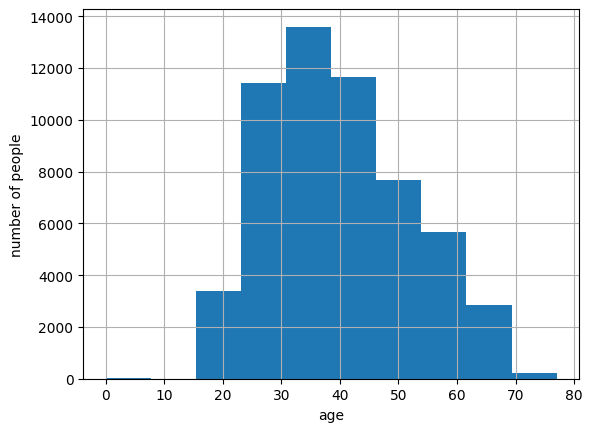

In [181]:
# Examine age distribution

X_train["age"].hist()
plt.xlabel("age")
plt.ylabel("number of people")
plt.show()

In [182]:
# there are a number of people who are under-aged.

# The business does not provide loans to under-aged,
# so we remove those from the datasets.

X_train[X_train["age"] < 18][["age", "application_date", "date_of_birth"]].head()

,age,application_date,date_of_birth
30394,0,2016-06-01 12:32:14,2015-10-10
8998,0,2014-08-26 08:44:07,2014-01-24
2634,0,2014-07-31 22:17:53,2014-04-13
20910,0,2016-03-11 10:54:08,2016-02-16
2560,0,2014-05-30 17:42:52,2014-05-25


In [183]:
# We need the indexes for the pipeline later on

X_train[X_train["age"] < 18].index


Index([30394,  8998,  2634, 20910,  2560,  2434,  1148,  2448,   889, 11656,
       18764,  1166, 11647,  2565, 18823,  2475,  2403,  8802,  9081,  2479,
       11557, 19035,  1132,  2439, 30369,  2423,  1174, 20932, 20892,   919,
       18765,  2589,  8770, 11386, 20941, 20895,   956, 11555,   930, 20925,
        2509],
      dtype='int64')

In [184]:
# Remove people under 18 from the data sets

X_train = X_train[X_train["age"] >= 18]
X_test = X_test[X_test["age"] >= 18]

In [185]:
# Adjust the target

y_train = y_train.loc[X_train.index]
y_test = y_test.loc[X_test.index]

In [186]:
X_train.shape, y_train.shape

((56489, 42), (56489,))

**Date and time features**


In [187]:
# Extract features from date and time of application

X_train["application_date"] = pd.to_datetime(X_train["application_date"])

X_train["dow"] = X_train["application_date"].dt.day_of_week
X_train["dom"] = X_train["application_date"].dt.day
X_train["month"] = X_train["application_date"].dt.month
X_train["hour"] = X_train["application_date"].dt.hour

X_train[["application_date", "dow", "dom", "month", "hour"]].head()

,application_date,dow,dom,month,hour
11155,2020-03-25 02:42:53,2,25,3,2
50730,2017-12-23 12:49:32,5,23,12,12
35924,2021-10-14 13:26:08,3,14,10,13
69230,2018-11-09 09:37:29,4,9,11,9
35679,2021-10-07 10:48:05,3,7,10,10


In [188]:
X_test["application_date"] = pd.to_datetime(X_test["application_date"])

X_test["dow"] = X_test["application_date"].dt.day_of_week
X_test["dom"] = X_test["application_date"].dt.day
X_test["month"] = X_test["application_date"].dt.month
X_test["hour"] = X_test["application_date"].dt.hour

In [189]:
# Drop temporal variables

X_train.drop(["application_date", "date_of_birth"], axis=1, inplace=True)
X_test.drop(["application_date", "date_of_birth"], axis=1, inplace=True)

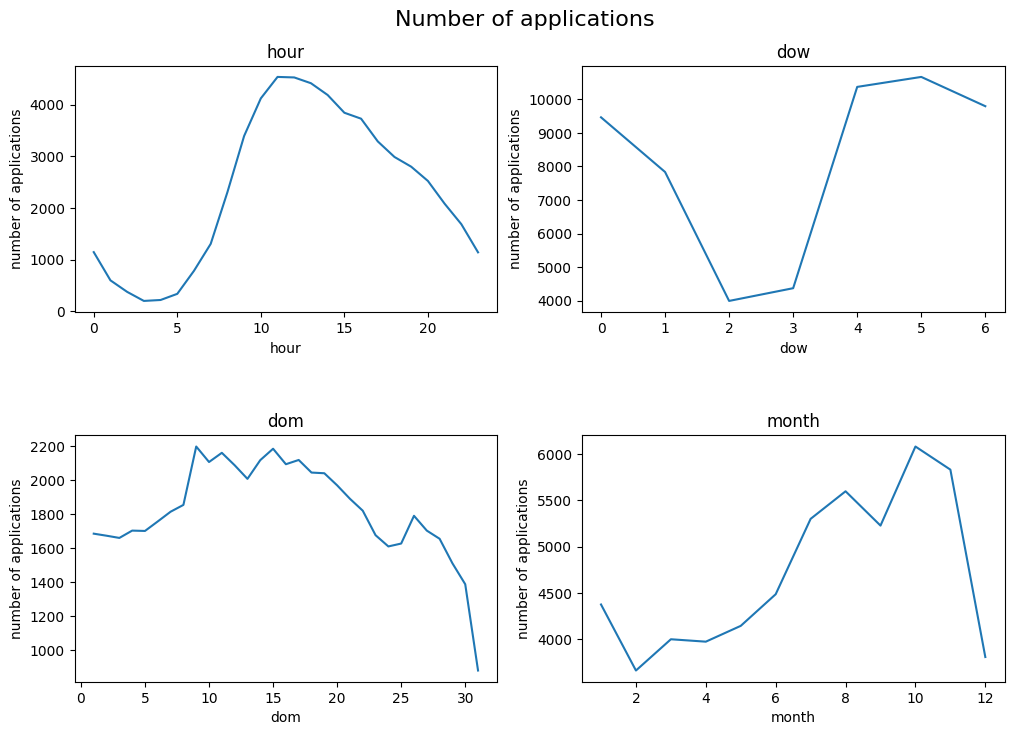

In [190]:
# Plot number of applications per temporal feature

# Define subplot grid
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
plt.subplots_adjust(hspace=0.5)
fig.suptitle("Number of applications", fontsize=16, y=0.95)

new_features = ["hour", "dow", "dom", "month"]

# loop through variables and axes
for var, ax in zip(new_features, axs.ravel()):

    # Plot the variable
    X_train.groupby(var)[var].count().plot(ax=ax)

    # Plot formatting
    ax.set_title(var)
    ax.set_ylabel("number of applications")


**Evaluate categorical variables**

In [191]:
# Identify variables cast as object

vars_cat = [x for x in X_train.select_dtypes(include="O").columns if x not in vars_temp]

vars_cat


['income_verification',
 'language',
 'gender',
 'country',
 'county',
 'city',
 'use_of_loan',
 'education',
 'marital_status',
 'employment_status',
 'employment_duration',
 'employment_position',
 'work_experience',
 'occupation',
 'home_ownership',
 'credit_score_1',
 'credit_score_2',
 'credit_score_3']

In [192]:
# display the categorical variable values

X_train[vars_cat].head(5)

,income_verification,language,gender,country,county,city,use_of_loan,education,marital_status,employment_status,employment_duration,employment_position,work_experience,occupation,home_ownership,credit_score_1,credit_score_2,credit_score_3
11155,unverified,spanish,female,ES,CATALUNYA,LLEIDA,loan_consolidation,secondary,divorced,retiree,UpTo5Years,Worker,15To25Years,other,tenant_furnished,M1,B,NaN
50730,income_and_expenses_verified,spanish,female,ES,MADRID,MADRID,other,higher,single,fully,UpTo5Years,telefonioperaator,15To25Years,telecom,tenant_furnished,M1,B,NaN
35924,income_and_expenses_verified,russian,male,EE,Harju maakond,Tallinn,unknown,higher,NaN,NaN,UpTo5Years,NaN,NaN,NaN,owner,M,NaN,NaN
69230,income_and_expenses_verified,estonian,male,EE,HARJU,TALLINN,vehicle,secondary,single,fully,UpTo2Years,Executive,10To15Years,construction,tenant_furnished,NaN,NaN,NaN
35679,unverified,russian,male,EE,Harju maakond,Tallinn,unknown,secondary,NaN,NaN,MoreThan5Years,NaN,NaN,NaN,owner,M,NaN,NaN


In [193]:
print(X_train[vars_cat].head())

                income_verification  language  gender country         county  \
11155                    unverified   spanish  female      ES      CATALUNYA   
50730  income_and_expenses_verified   spanish  female      ES         MADRID   
35924  income_and_expenses_verified   russian    male      EE  Harju maakond   
69230  income_and_expenses_verified  estonian    male      EE          HARJU   
35679                    unverified   russian    male      EE  Harju maakond   

          city         use_of_loan  education marital_status  \
11155   LLEIDA  loan_consolidation  secondary       divorced   
50730   MADRID               other     higher         single   
35924  Tallinn             unknown     higher            NaN   
69230  TALLINN             vehicle  secondary         single   
35679  Tallinn             unknown  secondary            NaN   

      employment_status employment_duration employment_position  \
11155           retiree          UpTo5Years              Worker   


**Cardinality**

<Axes: >

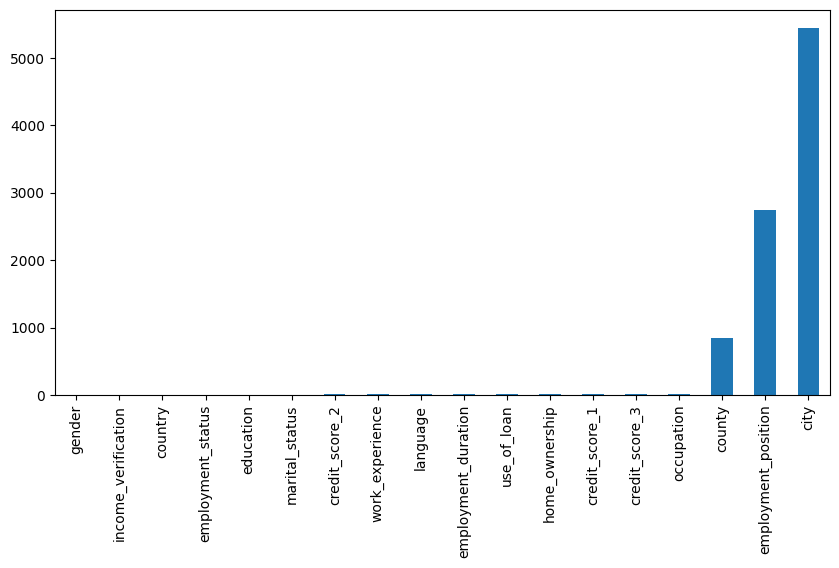

In [194]:
# Find the number of unique categories per variable

X_train[vars_cat].nunique().sort_values(ascending=True).plot.bar(figsize=(10, 5))

In [195]:
# Display values of highly cardinal variables

highly_cardinal_vars = ["employment_position", "city", "county"]

for var in highly_cardinal_vars:
    print(var)
    print(X_train[var].unique()[0:20])
    print()

employment_position
['Worker' 'telefonioperaator' nan 'Executive' 'MiddleManager'
 'SpecialistOfficeWorker' 'Camarero'
 'müügisekretär  ( hetkel kodune lapsega) ' 'Jurist' 'Autopesija' 'Owner'
 'Insener' 'Cámara y Periodista ' 'operaator-klienditeenindaja' 'liimia'
 'Comercial' 'operaator' 'Haljastustööline ' 'Tegevjuht' 'Linnu talitaja']

city
['LLEIDA' 'MADRID' 'Tallinn' 'TALLINN' nan 'Tahkuranna vald' 'Põlva vald'
 'MÁLAGA' 'PALDISKI' 'PORI' 'KOUVOLA' 'VALENCIA' 'VÕRU' 'Tartu linn'
 'LUIGE' 'Viljandi linn' 'Kanepi vald' 'KIURUVESI' 'ECIJA' 'MURASTE KÜLA']

county
['CATALUNYA' 'MADRID' 'Harju maakond' 'HARJU' nan 'Pärnu maakond'
 'Põlva maakond' 'ANDALUCÍA' 'VALENCIA' 'VÕRUMAA' 'Tartu maakond'
 'Viljandi maakond' 'SEVILLA' 'JÄRVAMAA' 'PIRKANMAA' 'COMUNIDAD DE MADRID'
 'PÄRNU' 'PÄRNU MAAKOND' 'ŽILINSKÝ KRAJ' 'Ida-Viru maakond']



In [196]:
# Drop highly cardinal variables

X_train.drop(highly_cardinal_vars, axis=1, inplace=True)
X_test.drop(highly_cardinal_vars, axis=1, inplace=True)

**Impute categorical variables**

In [197]:
# Adjust categorical variable list

vars_cat = [var for var in vars_cat if var not in highly_cardinal_vars]

In [198]:
# Find categorical variables with missing data

var_cat_na = [var for var in vars_cat if X_train[var].isnull().sum() > 0]

var_cat_na

['gender',
 'education',
 'marital_status',
 'employment_status',
 'employment_duration',
 'work_experience',
 'occupation',
 'home_ownership',
 'credit_score_1',
 'credit_score_2',
 'credit_score_3']

In [199]:
# We'll replace missing data with the string "missing"

imputation_cat_dict = {var: "missing" for var in var_cat_na}

imputation_cat_dict

{'gender': 'missing',
 'education': 'missing',
 'marital_status': 'missing',
 'employment_status': 'missing',
 'employment_duration': 'missing',
 'work_experience': 'missing',
 'occupation': 'missing',
 'home_ownership': 'missing',
 'credit_score_1': 'missing',
 'credit_score_2': 'missing',
 'credit_score_3': 'missing'}

In [200]:
# Impute categorical variables

X_train.fillna(value=imputation_cat_dict, inplace=True)
X_test.fillna(value=imputation_cat_dict, inplace=True)

In [201]:
# Corroborate absence of missing data

X_test[var_cat_na].isnull().sum()

gender                 0
education              0
marital_status         0
employment_status      0
employment_duration    0
work_experience        0
occupation             0
home_ownership         0
credit_score_1         0
credit_score_2         0
credit_score_3         0
dtype: int64

**Group rare categories**

In [202]:
# Number of categorical variables

len(vars_cat)


15

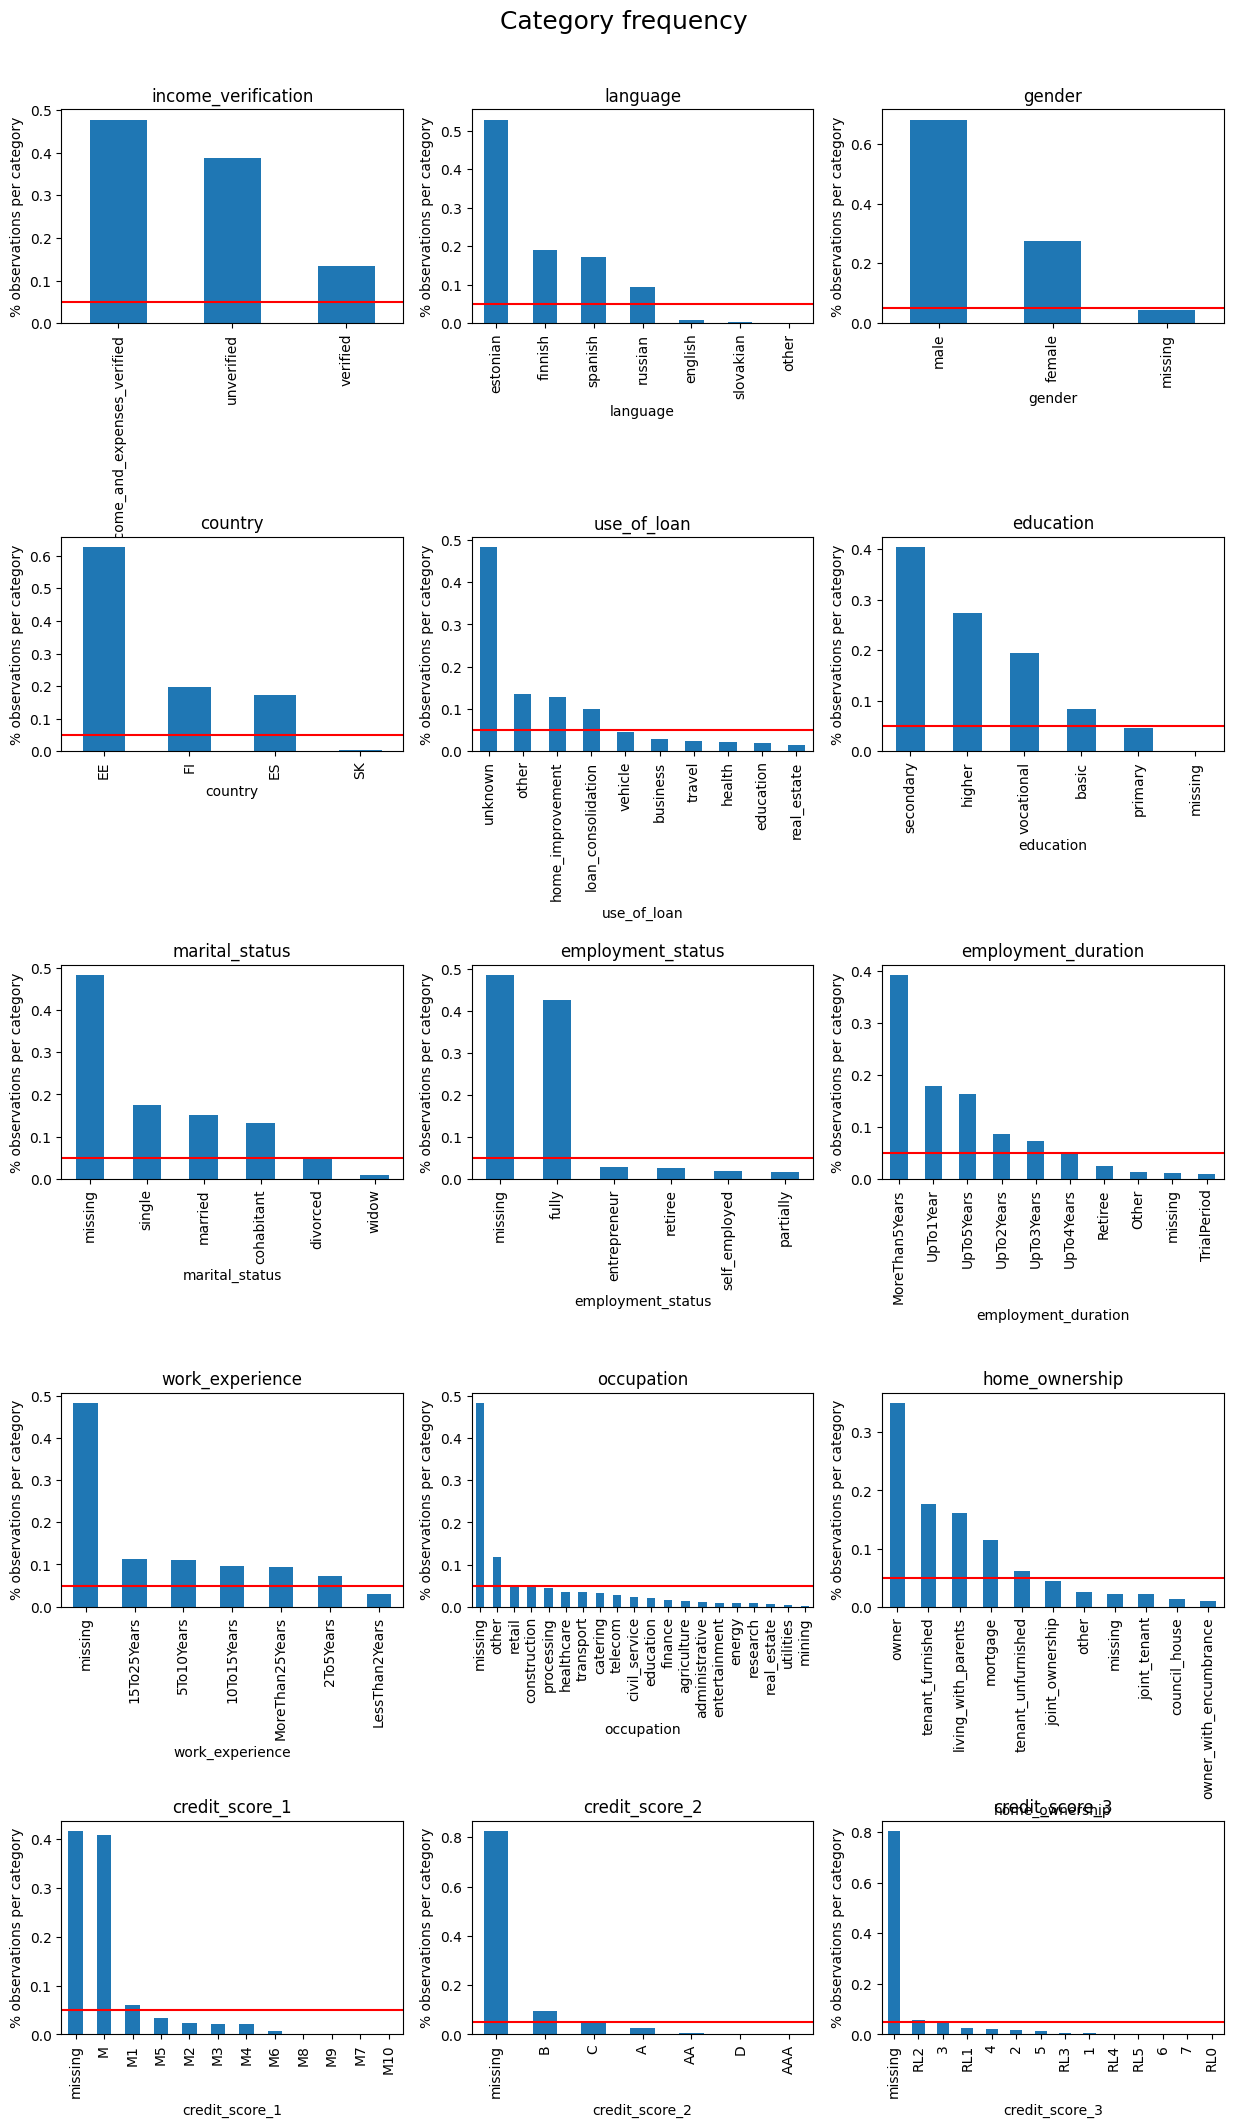

In [203]:
# Plot the fraction of observations per category
# in each categorical variable.

# Define subplot grid
fig, axs = plt.subplots(nrows=5, ncols=3, figsize=(15, 25))
plt.subplots_adjust(hspace=1)
fig.suptitle("Category frequency", fontsize=18, y=0.92)

# loop through variables and axes
for var, ax in zip(vars_cat, axs.ravel()):

    # Plot the variable
    X_train[var].value_counts(normalize=True, dropna=False).plot.bar(ax=ax)

    # Plot formatting
    ax.axhline(y=0.05, color="r", linestyle="-")
    ax.set_title(var)
    ax.set_ylabel("% observations per category")

In [204]:
# Variables with labels to group

vars_group = [
    "language",
    "use_of_loan",
    "occupation",
    "home_ownership",
    "credit_score_1",
    "credit_score_2",
    "credit_score_3",
]

In [205]:
# Find the most frequent categories in each variable

frequent_cat_dict = {}

for var in vars_group:
    categories = X_train[var].value_counts(normalize=True)
    categories = list(categories[categories > 0.05].index)
    frequent_cat_dict[var] = categories

frequent_cat_dict

{'language': ['estonian', 'finnish', 'spanish', 'russian'],
 'use_of_loan': ['unknown', 'other', 'home_improvement', 'loan_consolidation'],
 'occupation': ['missing', 'other', 'retail'],
 'home_ownership': ['owner',
  'tenant_furnished',
  'living_with_parents',
  'mortgage',
  'tenant_unfurnished'],
 'credit_score_1': ['missing', 'M', 'M1'],
 'credit_score_2': ['missing', 'B'],
 'credit_score_3': ['missing', 'RL2']}

In [206]:
# Replace rare categories by new value: Rare

from numpy import where

for var in vars_group:
    X_train[var] = where(
        X_train[var].isin(frequent_cat_dict[var]), X_train[var], "Rare"
    )

    X_test[var] = where(X_test[var].isin(frequent_cat_dict[var]), X_test[var], "Rare")

In [207]:
X_test["language"].value_counts(normalize=True)

language
estonian    0.541959
finnish     0.184973
spanish     0.166277
russian     0.093336
Rare        0.013455
Name: proportion, dtype: float64

**Encode categorical variables**

In [208]:
import joblib
from sklearn.preprocessing import OrdinalEncoder

In [209]:
# Set up and train encoder
enc = OrdinalEncoder()

enc.fit(X_train[vars_cat])

OrdinalEncoder()

In [210]:
enc.categories_


[array(['income_and_expenses_verified', 'unverified', 'verified'],
       dtype=object),
 array(['Rare', 'estonian', 'finnish', 'russian', 'spanish'], dtype=object),
 array(['female', 'male', 'missing'], dtype=object),
 array(['EE', 'ES', 'FI', 'SK'], dtype=object),
 array(['Rare', 'home_improvement', 'loan_consolidation', 'other',
        'unknown'], dtype=object),
 array(['basic', 'higher', 'missing', 'primary', 'secondary', 'vocational'],
       dtype=object),
 array(['cohabitant', 'divorced', 'married', 'missing', 'single', 'widow'],
       dtype=object),
 array(['entrepreneur', 'fully', 'missing', 'partially', 'retiree',
        'self_employed'], dtype=object),
 array(['MoreThan5Years', 'Other', 'Retiree', 'TrialPeriod', 'UpTo1Year',
        'UpTo2Years', 'UpTo3Years', 'UpTo4Years', 'UpTo5Years', 'missing'],
       dtype=object),
 array(['10To15Years', '15To25Years', '2To5Years', '5To10Years',
        'LessThan2Years', 'MoreThan25Years', 'missing'], dtype=object),
 array(['Rare', 

In [211]:
# Encode categorical variables

X_train[vars_cat] = enc.transform(X_train[vars_cat])
X_test[vars_cat] = enc.transform(X_test[vars_cat])

In [212]:
# Display new values

X_train[vars_cat].head(5)

,income_verification,language,gender,country,use_of_loan,education,marital_status,employment_status,employment_duration,work_experience,occupation,home_ownership,credit_score_1,credit_score_2,credit_score_3
11155,1.0,4.0,0.0,1.0,2.0,4.0,1.0,4.0,8.0,1.0,2.0,4.0,1.0,0.0,2.0
50730,0.0,4.0,0.0,1.0,3.0,1.0,4.0,1.0,8.0,1.0,0.0,4.0,1.0,0.0,2.0
35924,0.0,3.0,1.0,0.0,4.0,1.0,3.0,2.0,8.0,6.0,1.0,3.0,0.0,2.0,2.0
69230,0.0,1.0,1.0,0.0,0.0,4.0,4.0,1.0,5.0,0.0,0.0,4.0,3.0,2.0,2.0
35679,1.0,3.0,1.0,0.0,4.0,4.0,3.0,2.0,0.0,6.0,1.0,3.0,0.0,2.0,2.0


In [213]:
print(X_train[vars_cat].head(5))


       income_verification  language  gender  country  use_of_loan  education  \
11155                  1.0       4.0     0.0      1.0          2.0        4.0   
50730                  0.0       4.0     0.0      1.0          3.0        1.0   
35924                  0.0       3.0     1.0      0.0          4.0        1.0   
69230                  0.0       1.0     1.0      0.0          0.0        4.0   
35679                  1.0       3.0     1.0      0.0          4.0        4.0   

       marital_status  employment_status  employment_duration  \
11155             1.0                4.0                  8.0   
50730             4.0                1.0                  8.0   
35924             3.0                2.0                  8.0   
69230             4.0                1.0                  5.0   
35679             3.0                2.0                  0.0   

       work_experience  occupation  home_ownership  credit_score_1  \
11155              1.0         2.0             4.0  

In [214]:
# Check that no missing data was introduced

X_test[vars_cat].isnull().sum()


income_verification    0
language               0
gender                 0
country                0
use_of_loan            0
education              0
marital_status         0
employment_status      0
employment_duration    0
work_experience        0
occupation             0
home_ownership         0
credit_score_1         0
credit_score_2         0
credit_score_3         0
dtype: int64

In [215]:
# Save encoder for later

joblib.dump(enc, "encoder.pkl")

['encoder.pkl']

**Train and evaluate a LightGBM**

In [216]:
import lightgbm as lgb

In [217]:
# set up model

gbm = lgb.LGBMClassifier(
    num_iterations=1000,
    random_state=seed,
)

In [218]:
evals_result = {}  # to record eval results for plotting

# train model
gbm.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    categorical_feature=vars_cat,
    callbacks=[
        lgb.early_stopping(3),
        lgb.record_evaluation(evals_result),
    ],
)

/workspaces/feature-engineering-lgbm-pipeline/venv/lib/python3.12/site-packages/lightgbm/engine.py:172: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


[LightGBM] [Info] Number of positive: 37116, number of negative: 19373
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012476 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3737
[LightGBM] [Info] Number of data points in the train set: 56489, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.657048 -> initscore=0.650168
[LightGBM] [Info] Start training from score 0.650168
Training until validation scores don't improve for 3 rounds
Early stopping, best iteration is:
[114]	valid_0's binary_logloss: 0.567278


LGBMClassifier(num_iterations=1000, random_state=10)

**Learning optimization**

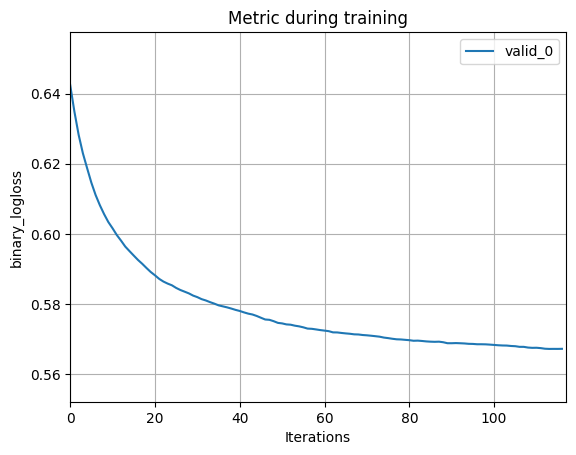

In [219]:
ax = lgb.plot_metric(evals_result, metric="binary_logloss")

plt.show()

**Evaluate**

In [220]:
from sklearn.metrics import roc_auc_score, classification_report

In [221]:
pred_train = gbm.predict_proba(X_train)[:, 1]
pred_test = gbm.predict_proba(X_test)[:, 1]

roc_train = roc_auc_score(y_train, pred_train)
roc_test = roc_auc_score(y_test, pred_test)

print(f"Train set roc-auc: {roc_train}")
print(f"Eval set roc-auc: {roc_test}")

Train set roc-auc: 0.7922777480356853
Eval set roc-auc: 0.7376127137927155


In [222]:
pred_train = gbm.predict(X_train)
pred_test = gbm.predict(X_test)

cr_train = classification_report(y_train, pred_train)
cr_test = classification_report(y_test, pred_test)

print(f"Train set:\n {cr_train}")
print(f"Eval set:\n {cr_test}")

Train set:
               precision    recall  f1-score   support

           0       0.72      0.43      0.54     19373
           1       0.75      0.91      0.83     37116

    accuracy                           0.75     56489
   macro avg       0.74      0.67      0.68     56489
weighted avg       0.74      0.75      0.73     56489

Eval set:
               precision    recall  f1-score   support

           0       0.65      0.38      0.48      5034
           1       0.72      0.89      0.80      9087

    accuracy                           0.71     14121
   macro avg       0.69      0.63      0.64     14121
weighted avg       0.70      0.71      0.68     14121



In [223]:
joblib.dump(gbm, "lightGBM.pkl")

['lightGBM.pkl']

**Evaluate feature importance**

Feature importance according to lightGBM

In [224]:
# Total number of input features

len(X_train.columns)

41

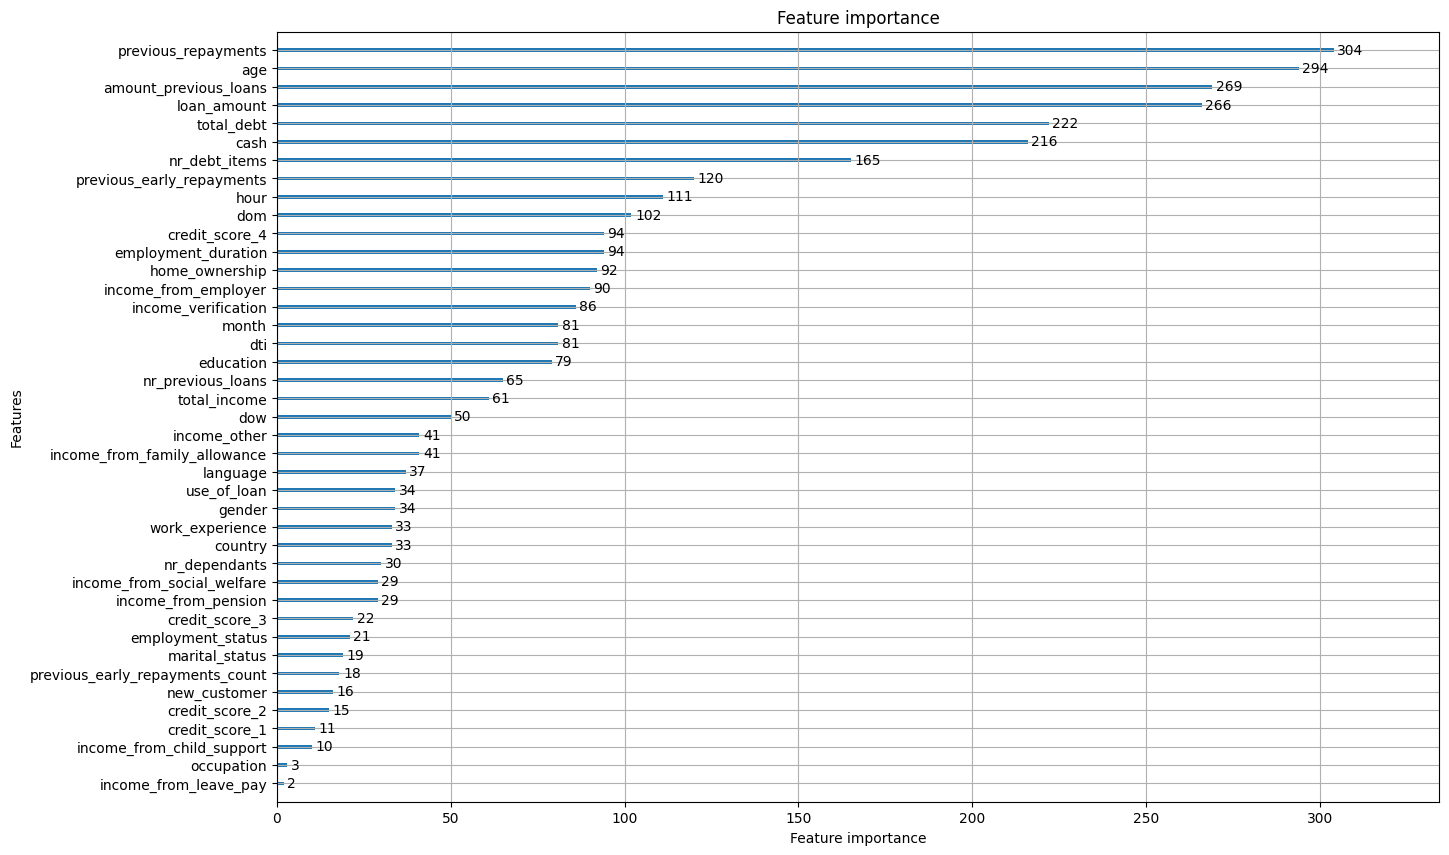

In [225]:
# Plot feature importance according to lightGBM

ax = lgb.plot_importance(gbm, figsize=(15, 10))

plt.show()


**According to lightGBM all features are important.**

Feature permutation importance

In [226]:
from sklearn.inspection import permutation_importance

In [227]:
# Shuffle features and evaluate performance drop

result = permutation_importance(
    gbm,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=3,
    random_state=seed,
)

Text(0, 0.5, 'permutation importance')

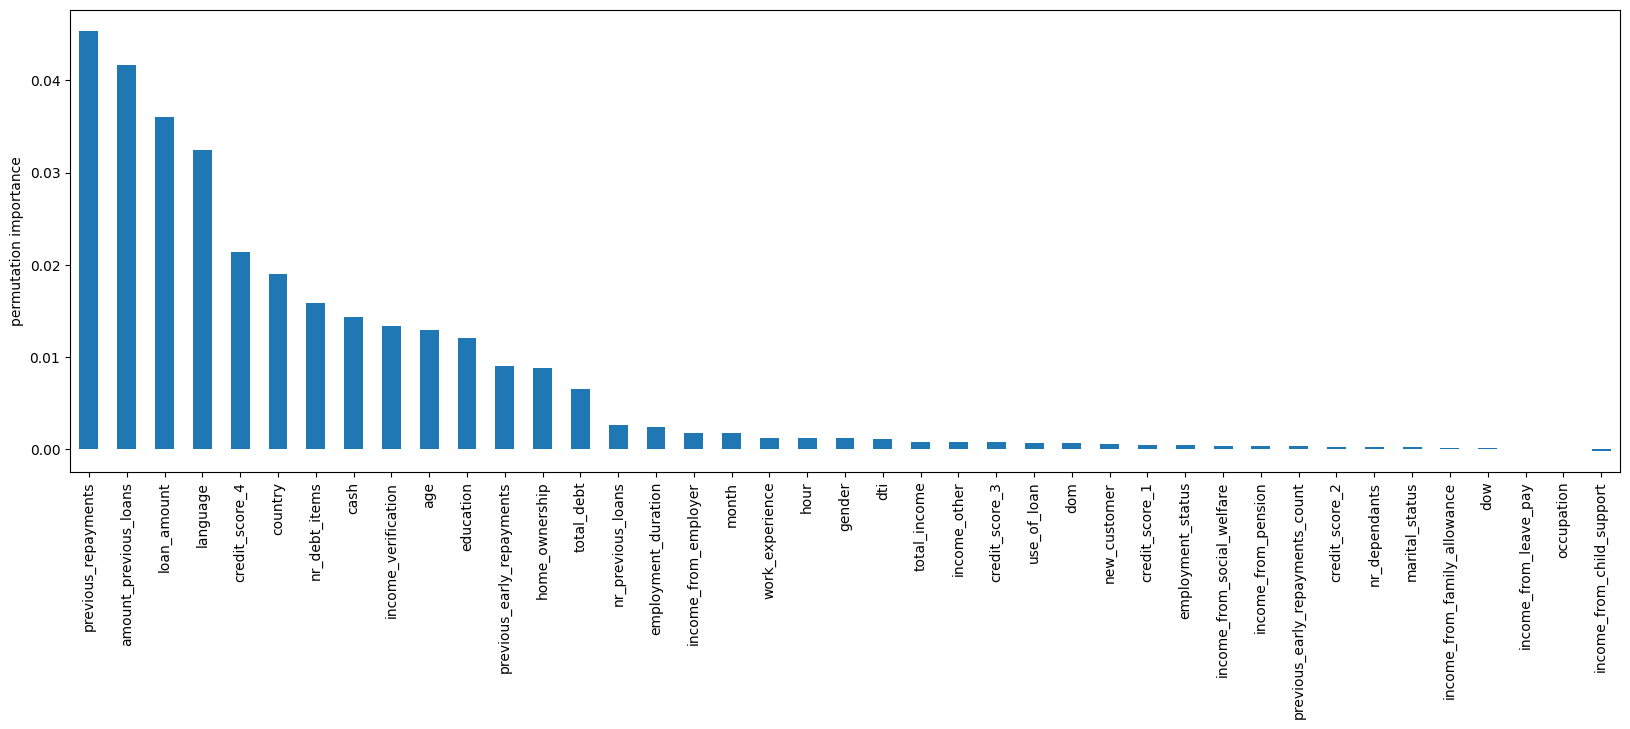

In [228]:
# PLot drop in performance per shuffled feature

result = pd.Series(result.importances_mean, index=X_train.columns)

result.sort_values(ascending=False).plot.bar(figsize=(20, 6))
plt.ylabel("permutation importance")

In [229]:
# Find fetures whose shuffling caused a drop in model performance

feature_subset_1 = list((result > 0).index)

print(len(feature_subset_1))

feature_subset_1

41


['new_customer',
 'income_verification',
 'language',
 'gender',
 'country',
 'loan_amount',
 'use_of_loan',
 'education',
 'marital_status',
 'nr_dependants',
 'employment_status',
 'employment_duration',
 'work_experience',
 'occupation',
 'home_ownership',
 'income_from_employer',
 'income_from_pension',
 'income_from_family_allowance',
 'income_from_social_welfare',
 'income_from_leave_pay',
 'income_from_child_support',
 'income_other',
 'nr_debt_items',
 'total_debt',
 'credit_score_1',
 'credit_score_2',
 'credit_score_3',
 'credit_score_4',
 'nr_previous_loans',
 'amount_previous_loans',
 'previous_repayments',
 'previous_early_repayments',
 'previous_early_repayments_count',
 'total_income',
 'dti',
 'cash',
 'age',
 'dow',
 'dom',
 'month',
 'hour']

According to permutation importance, all features are important.

**Single feature classifier**

Train a decision tree per feature and evaluate its model performance.

In [230]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate

In [231]:
# Set up decision tree

clf = DecisionTreeClassifier(random_state=seed)

In [232]:
# Dictionary to store single feature classifier performance
result = {}

# Loop over every feature
for var in X_train.columns:

    # Train and evaluate a classifier with crossvalidation
    tmp = cross_validate(
        clf,
        X_train[var].to_frame(),
        y_train,
        cv=3,
        scoring="roc_auc",
    )

    # Store the result
    result[var] = tmp["test_score"].mean()

result

{'new_customer': 0.5227159532425611,
 'income_verification': 0.5265436119059705,
 'language': 0.6187208715892115,
 'gender': 0.5227554194782317,
 'country': 0.6124701908656466,
 'loan_amount': 0.5905094380584909,
 'use_of_loan': 0.5144123587323483,
 'education': 0.5496562906104216,
 'marital_status': 0.5270836330469217,
 'nr_dependants': 0.5148170174944456,
 'employment_status': 0.5228495390670609,
 'employment_duration': 0.5076661704400346,
 'work_experience': 0.5116961069881364,
 'occupation': 0.5147616518098598,
 'home_ownership': 0.5470854928154826,
 'income_from_employer': 0.5355103910719149,
 'income_from_pension': 0.5072014419194489,
 'income_from_family_allowance': 0.5142669903503824,
 'income_from_social_welfare': 0.4999813726213899,
 'income_from_leave_pay': 0.5016003451487093,
 'income_from_child_support': 0.501066520865094,
 'income_other': 0.515108559331898,
 'nr_debt_items': 0.5169827303328545,
 'total_debt': 0.5211988710022629,
 'credit_score_1': 0.5654576558299365,
 'cr

Text(0, 0.5, 'permutation importance')

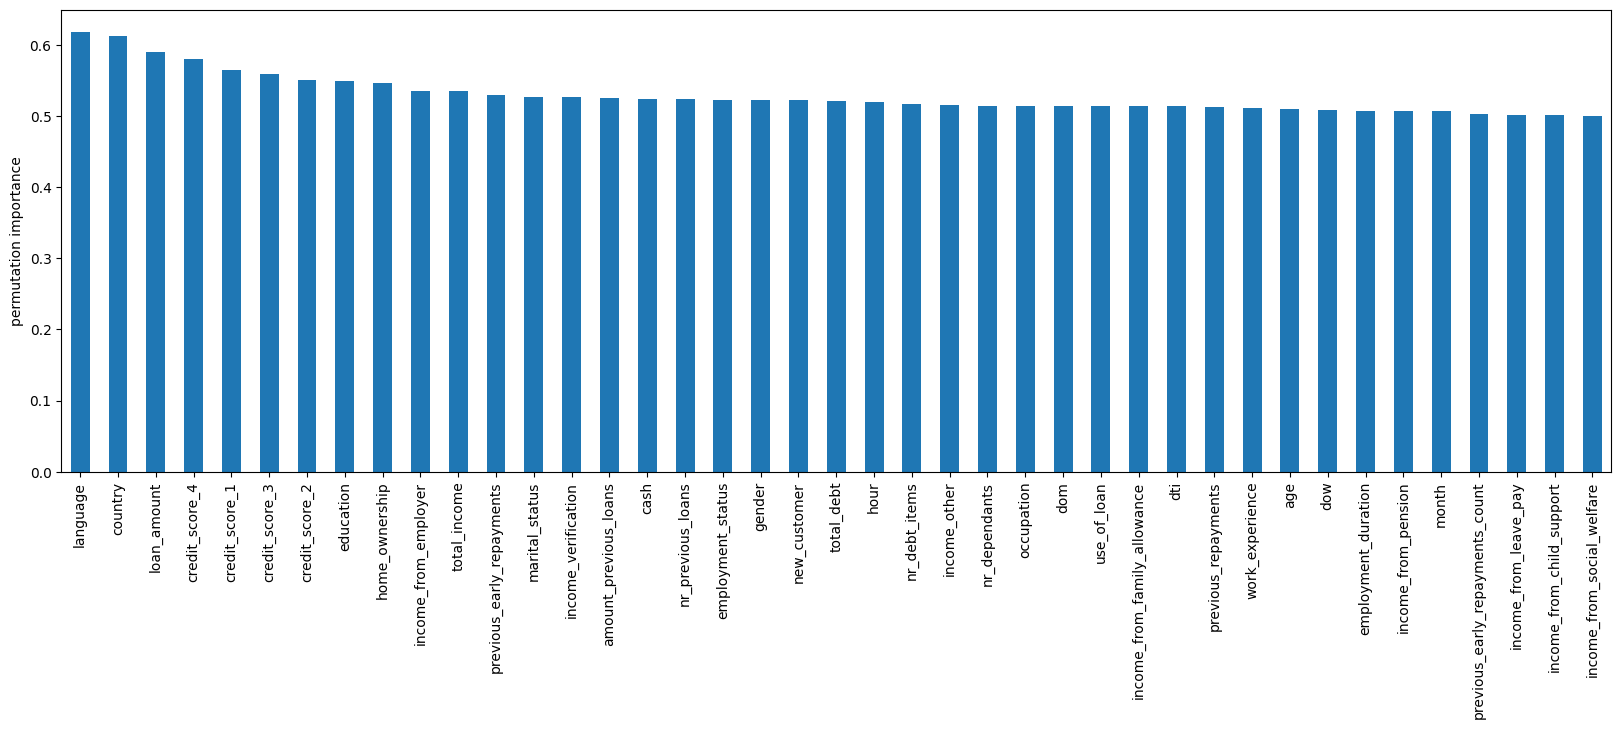

In [233]:
# PLot roc-auc per feature

result = pd.Series(result, index=X_train.columns)

result.sort_values(ascending=False).plot.bar(figsize=(20, 6))
plt.ylabel("permutation importance")

In [234]:
# Find fetures with roc-auc greater than 0.5

feature_subset_2 = list((result > 0.5).index)

print(len(feature_subset_2))

feature_subset_2

41


['new_customer',
 'income_verification',
 'language',
 'gender',
 'country',
 'loan_amount',
 'use_of_loan',
 'education',
 'marital_status',
 'nr_dependants',
 'employment_status',
 'employment_duration',
 'work_experience',
 'occupation',
 'home_ownership',
 'income_from_employer',
 'income_from_pension',
 'income_from_family_allowance',
 'income_from_social_welfare',
 'income_from_leave_pay',
 'income_from_child_support',
 'income_other',
 'nr_debt_items',
 'total_debt',
 'credit_score_1',
 'credit_score_2',
 'credit_score_3',
 'credit_score_4',
 'nr_previous_loans',
 'amount_previous_loans',
 'previous_repayments',
 'previous_early_repayments',
 'previous_early_repayments_count',
 'total_income',
 'dti',
 'cash',
 'age',
 'dow',
 'dom',
 'month',
 'hour']

Based on single feature classifiers, all features are important.

In [235]:
# Model input features, we need them for the pipeline

X_train.columns

Index(['new_customer', 'income_verification', 'language', 'gender', 'country',
       'loan_amount', 'use_of_loan', 'education', 'marital_status',
       'nr_dependants', 'employment_status', 'employment_duration',
       'work_experience', 'occupation', 'home_ownership',
       'income_from_employer', 'income_from_pension',
       'income_from_family_allowance', 'income_from_social_welfare',
       'income_from_leave_pay', 'income_from_child_support', 'income_other',
       'nr_debt_items', 'total_debt', 'credit_score_1', 'credit_score_2',
       'credit_score_3', 'credit_score_4', 'nr_previous_loans',
       'amount_previous_loans', 'previous_repayments',
       'previous_early_repayments', 'previous_early_repayments_count',
       'total_income', 'dti', 'cash', 'age', 'dow', 'dom', 'month', 'hour'],
      dtype='object')

**Credit risk pipeline**

**Create a pipeline**

In [236]:
import joblib
import pandas as pd

from numpy import inf, nan, where
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.model_selection import train_test_split

In [237]:
# variable groups - constants

# The features needed to create all input features
FEATURES_ALL = [
    'new_customer', 'application_date', 'income_verification', 'language',
    'date_of_birth', 'gender', 'country', 'loan_amount', 'county', 'city',
    'use_of_loan', 'education', 'marital_status', 'nr_dependants',
    'employment_status', 'employment_duration', 'employment_position',
    'work_experience', 'occupation', 'home_ownership',
    'income_from_employer', 'income_from_pension',
    'income_from_family_allowance', 'income_from_social_welfare',
    'income_from_leave_pay', 'income_from_child_support', 'income_other',
    'nr_debt_items', 'total_debt', 'credit_score_1', 'credit_score_2',
    'credit_score_3', 'credit_score_4', 'nr_previous_loans',
    'amount_previous_loans', 'previous_repayments',
    'previous_early_repayments', 'previous_early_repayments_count'
]

# Input features to the model (important: mind 
# the order used when training the model)
FEATURES_INPUT = [
    'new_customer', 'income_verification', 'language', 'gender', 'country',
    'loan_amount', 'use_of_loan', 'education', 'marital_status',
    'nr_dependants', 'employment_status', 'employment_duration',
    'work_experience', 'occupation', 'home_ownership',
    'income_from_employer', 'income_from_pension',
    'income_from_family_allowance', 'income_from_social_welfare',
    'income_from_leave_pay', 'income_from_child_support', 'income_other',
    'nr_debt_items', 'total_debt', 'credit_score_1', 'credit_score_2',
    'credit_score_3', 'credit_score_4', 'nr_previous_loans',
    'amount_previous_loans', 'previous_repayments',
    'previous_early_repayments', 'previous_early_repayments_count',
    'total_income', 'dti', 'cash', 'age', 'dow', 'dom', 'month', 'hour',
]

FEATURES_INCOME = [
    'income_from_employer',
    'income_from_pension',
    'income_from_family_allowance',
    'income_from_social_welfare',
    'income_from_leave_pay',
    'income_from_child_support',
    'income_other',
]


FEATURES_ENCODE = [
    'income_verification',
    'language',
    'gender',
    'country',
    'use_of_loan',
    'education',
    'marital_status',
    'employment_status',
    'employment_duration',
    'work_experience',
    'occupation',
    'home_ownership',
    'credit_score_1',
    'credit_score_2',
    'credit_score_3',
]

In [238]:
# Parameters learned during model development

# Imputation values

IMPUTATION_DICT = {
    'nr_dependants': -1,
    'credit_score_4': -1,
    'previous_repayments': -1,
    'previous_early_repayments': -1,
    'gender': 'missing',
    'education': 'missing',
    'marital_status': 'missing',
    'employment_status': 'missing',
    'employment_duration': 'missing',
    'work_experience': 'missing',
    'occupation': 'missing',
    'home_ownership': 'missing',
    'credit_score_1': 'missing',
    'credit_score_2': 'missing',
    'credit_score_3': 'missing',
}

# Frequent categories

FREQUENT_CAT_DICT = {
    'language': ['estonian', 'finnish', 'spanish', 'russian'],
    'use_of_loan': ['unknown', 'other', 'home_improvement', 'loan_consolidation'],
    'occupation': ['missing', 'other', 'retail'],
    'home_ownership': ['owner',
                       'tenant_furnished',
                       'living_with_parents',
                       'mortgage',
                       'tenant_unfurnished'],
    'credit_score_1': ['missing', 'M', 'M1'],
    'credit_score_2': ['missing', 'B'],
    'credit_score_3': ['missing', 'RL2']
}

In [257]:
def feature_engineering_pipe(df):
    import numpy as np
    
    # Make a copy of the input features
    df = df[FEATURES_ALL].copy()
    
    # Impute missing data
    df.fillna(IMPUTATION_DICT, inplace=True)
    
    # Create income related variables
    df['total_income'] = df[FEATURES_INCOME].sum(axis=1)
    
    df["dti"] = df["total_debt"].div(df["total_income"])
    df["dti"] = np.where(np.isfinite(df["dti"]), df["dti"], 0)  # fixed
    
    df["cash"] = df["total_income"].sub(df["total_debt"])
    
    # Create datetime related features
    df["age"] = ((pd.to_datetime(df["application_date"]) -
                  pd.to_datetime(df["date_of_birth"])).dt.days / 365).astype(int)
    
    df["application_date"] = pd.to_datetime(df["application_date"])
    df["dow"] = df["application_date"].dt.day_of_week
    df["dom"] = df["application_date"].dt.day
    df["month"] = df["application_date"].dt.month
    df["hour"] = df["application_date"].dt.hour
    
    # Group infrequent labels
    for var in FREQUENT_CAT_DICT.keys():
        df[var] = where(df[var].isin(
            FREQUENT_CAT_DICT[var]), df[var], "Rare")
    
    # Encode categorical variables
    df[FEATURES_ENCODE] = enc.transform(df[FEATURES_ENCODE])
    
    # Return features in the order in which they were passed to the
    # model during training
    return df[FEATURES_INPUT]

In [258]:
# Load models

enc = joblib.load("encoder.pkl")
gbm = joblib.load("lightGBM.pkl")

**Load and split data**

In [259]:
# load data

df = pd.read_csv("loan_data.csv", low_memory=False)

df.head()

,new_customer,application_date,income_verification,language,date_of_birth,gender,country,loan_amount,county,city,...,credit_score_1,credit_score_2,credit_score_3,credit_score_4,nr_previous_loans,amount_previous_loans,previous_repayments,previous_early_repayments,previous_early_repayments_count,default
0,1,2013-06-10 16:40:39,unverified,estonian,1951-11-25,female,EE,319.5582,HARJU,TALLINN,...,NaN,NaN,NaN,NaN,1,83.0852,0.0000,0.0,0,0
1,0,2013-06-09 15:48:57,unverified,estonian,1964-11-04,female,EE,191.7349,IDA-VIRU,KOHTLA-JARVE,...,NaN,NaN,NaN,NaN,2,255.6467,258.6256,0.0,0,0
2,1,2013-06-04 19:12:29,unverified,estonian,1954-11-12,female,EE,319.5582,PÄRNU,PÄRNU,...,NaN,NaN,NaN,NaN,0,0.0000,0.0000,0.0,0,1
3,1,2013-06-12 12:01:20,unverified,estonian,1990-03-28,female,EE,127.8233,HARJU,PALDISKI,...,NaN,NaN,NaN,NaN,1,134.2144,0.0000,0.0,0,0
4,1,2013-06-09 10:17:13,unverified,estonian,1987-09-29,female,EE,319.5582,TARTU,TARTU,...,NaN,NaN,NaN,NaN,1,146.9966,0.0000,0.0,0,1


In [260]:
seed = 10

In [261]:
# split data

X_train, X_test, y_train, y_test = train_test_split(
    df.drop("default", axis=1),
    df["default"],
    test_size=0.20,
    random_state=seed,
)

X_train.shape, X_test.shape

((56530, 38), (14133, 38))

**Remove customers that are under-aged**

In [262]:
train_index = [
    30394,  8998,  2634, 20910,  2560,  2434,  1148,  2448,   889,
    11656, 18764,  1166, 11647,  2565, 18823,  2475,  2403,  8802,
    9081,  2479, 11557, 19035,  1132,  2439, 30369,  2423,  1174,
    20932, 20892,   919, 18765,  2589,  8770, 11386, 20941, 20895,
    956, 11555,   930, 20925,  2509,
]


test_index = [
    915, 30378, 18914, 922, 18842, 8939, 2486, 30412, 11676, 1137,
    2440, 2447
]

X_train = X_train.drop(index=train_index)
X_test = X_test.drop(index=test_index)

y_train = y_train.drop(index=train_index)
y_test = y_test.drop(index=test_index)

In [263]:
X_train.shape, X_test.shape

((56489, 38), (14121, 38))

In [264]:
y_train.shape, y_test.shape


((56489,), (14121,))

**Create features**

In [265]:
X_train_t = feature_engineering_pipe(X_train)
X_test_t = feature_engineering_pipe(X_test)

**Evaluate model**

In [266]:
pred_train = gbm.predict_proba(X_train_t)[:, 1]
pred_test = gbm.predict_proba(X_test_t)[:, 1]

roc_train = roc_auc_score(y_train, pred_train)
roc_test = roc_auc_score(y_test, pred_test)

print(f"Train set roc-auc: {roc_train}")
print(f"Eval set roc-auc: {roc_test}")

Train set roc-auc: 0.7922777480356853
Eval set roc-auc: 0.7376127137927155


In [267]:
pred_train = gbm.predict(X_train_t)
pred_test = gbm.predict(X_test_t)

cr_train = classification_report(y_train, pred_train)
cr_test = classification_report(y_test, pred_test)

print(f"Train set:\n {cr_train}")
print(f"Eval set:\n {cr_test}")

Train set:
               precision    recall  f1-score   support

           0       0.72      0.43      0.54     19373
           1       0.75      0.91      0.83     37116

    accuracy                           0.75     56489
   macro avg       0.74      0.67      0.68     56489
weighted avg       0.74      0.75      0.73     56489

Eval set:
               precision    recall  f1-score   support

           0       0.65      0.38      0.48      5034
           1       0.72      0.89      0.80      9087

    accuracy                           0.71     14121
   macro avg       0.69      0.63      0.64     14121
weighted avg       0.70      0.71      0.68     14121



**Evaluate new cohort of customers**

In [268]:
# load data

df = pd.read_csv("latest_customers.csv", low_memory=False)

df.head()

,new_customer,application_date,income_verification,language,date_of_birth,gender,country,loan_amount,county,city,...,credit_score_1,credit_score_2,credit_score_3,credit_score_4,nr_previous_loans,amount_previous_loans,previous_repayments,previous_early_repayments,previous_early_repayments_count,default
0,0,2022-11-25 14:11:18,unverified,estonian,1984-12-14,male,EE,1590.0,Harju maakond,Tallinn,...,M,NaN,NaN,1000.0,7,10715.0,79.04,NaN,1,0
1,1,2022-11-25 14:20:44,unverified,russian,1995-04-23,male,EE,2445.0,Ida-Viru maakond,Kohtla-Järve linn,...,M,NaN,NaN,1000.0,0,0.0,NaN,NaN,0,0
2,1,2022-11-25 11:30:01,unverified,finnish,1970-11-03,male,FI,2230.0,NaN,KERAVA,...,M,NaN,3.0,NaN,0,0.0,NaN,NaN,0,0
3,1,2022-11-25 14:41:17,unverified,estonian,1996-05-10,male,EE,530.0,Lääne-Viru maakond,Haljala vald,...,M,NaN,NaN,1000.0,1,3185.0,289.82,NaN,0,1
4,1,2022-11-25 11:55:25,income_and_expenses_verified,finnish,1977-02-24,female,FI,2655.0,NaN,VETELI,...,M,NaN,1.0,NaN,0,0.0,NaN,NaN,0,0


In [269]:
# store target for later

df_target = df["default"]

In [270]:
 #create features

df_t = feature_engineering_pipe(df)

In [271]:
# determine roc-auc

pred_df = gbm.predict_proba(df_t)[:, 1]
roc_df = roc_auc_score(df_target, pred_df)
print(f"roc-auc: {roc_df}")

roc-auc: 0.6921039231086026


In [272]:
# determine classification report

pred_df = gbm.predict(df_t)
cr_df = classification_report(df_target, pred_df)

print(f"New data set:\n {cr_df}")

New data set:
               precision    recall  f1-score   support

           0       0.67      0.29      0.41      2572
           1       0.65      0.90      0.75      3697

    accuracy                           0.65      6269
   macro avg       0.66      0.60      0.58      6269
weighted avg       0.66      0.65      0.61      6269

